<a href="https://colab.research.google.com/github/pooja07ts-alt/DAA-LAB-EX-1/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Array: [2, 5, 10, 15, 23, 35, 48, 60, 75, 90, 105, 120]
Searching for: 35
Found at index: 5, Comparisons: 3

      Size    IS Time(ms)    BS Time(ms)   IS Comparisons   BS Comparisons
---------------------------------------------------------------------------
      1000         0.0010         0.0022                2               10
      5000         0.0019         0.0017                5               11
     10000         0.0012         0.0018                3               11
     50000         0.0021         0.0026                5               16
    100000         0.0019         0.0026                5               16


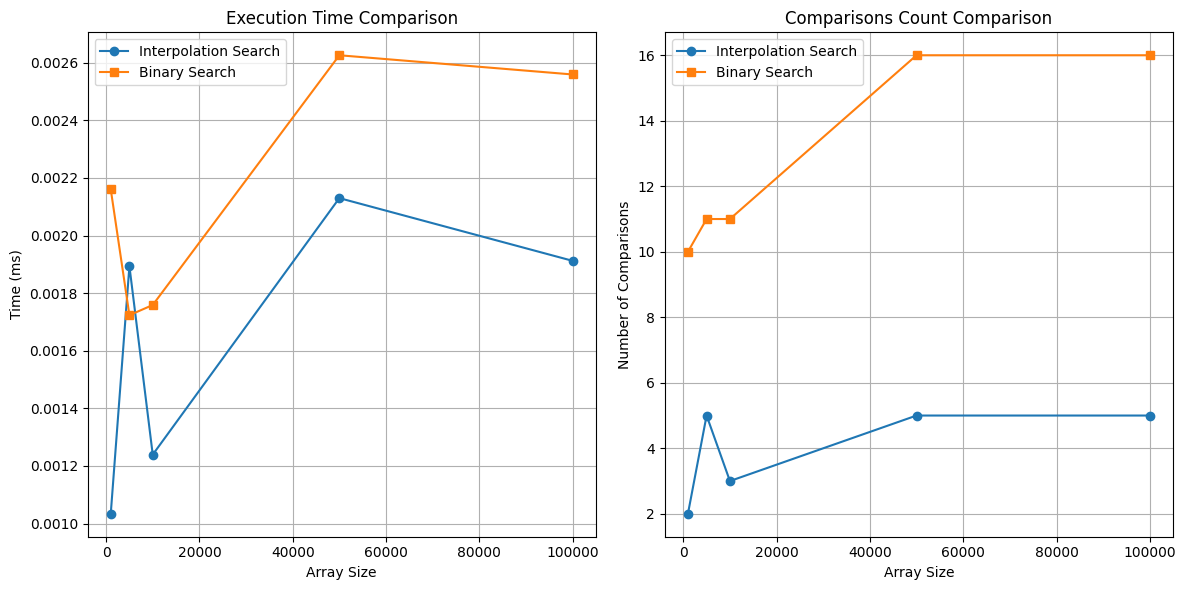

In [5]:
import time
import random
import sys

def interpolation_search(arr, target):
    """
    Interpolation Search Algorithm
    Time Complexity: O(log log n) average, O(n) worst case
    Space Complexity: O(1)
    """
    low, high = 0, len(arr) - 1
    comparisons = 0

    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            if arr[low] == target:
                return low, comparisons
            return -1, comparisons

        # Interpolation formula
        pos = low + int(((target - arr[low]) * (high - low))
                        / (arr[high] - arr[low]))

        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, comparisons

def binary_search(arr, target):
    """Binary Search for comparison"""
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons

def performance_analysis():
    sizes = [1000, 5000, 10000, 50000, 100000]
    is_times, bs_times = [], []
    is_comps, bs_comps = [], []

    print(f"{'Size':>10} {'IS Time(ms)':>14} {'BS Time(ms)':>14} "
          f"{'IS Comparisons':>16} {'BS Comparisons':>16}")
    print('-' * 75)

    for size in sizes:
        arr = sorted(random.sample(range(size * 10), size))
        target = arr[random.randint(0, size - 1)]

        # Interpolation Search timing
        start = time.perf_counter()
        for _ in range(100):
            idx_is, comp_is = interpolation_search(arr, target)
        is_time = (time.perf_counter() - start) / 100 * 1000

        # Binary Search timing
        start = time.perf_counter()
        for _ in range(100):
            idx_bs, comp_bs = binary_search(arr, target)
        bs_time = (time.perf_counter() - start) / 100 * 1000

        print(f"{size:>10} {is_time:>14.4f} {bs_time:>14.4f} "
              f"{comp_is:>16} {comp_bs:>16}")

        # Collect data for plotting
        is_times.append(is_time)
        bs_times.append(bs_time)
        is_comps.append(comp_is)
        bs_comps.append(comp_bs)

    # ✅ Call chart function here, after loop ends
    plot_results(sizes, is_times, bs_times, is_comps, bs_comps)


# --- Main ---
arr = [2, 5, 10, 15, 23, 35, 48, 60, 75, 90, 105, 120]
target = 35
idx, comps = interpolation_search(arr, target)
print(f"Array: {arr}")
print(f"Searching for: {target}")
print(f"Found at index: {idx}, Comparisons: {comps}")
print()
performance_analysis()
import matplotlib.pyplot as plt

def plot_results(sizes, is_times, bs_times, is_comps, bs_comps):
    plt.figure(figsize=(12, 6))

    # Time comparison
    plt.subplot(1, 2, 1)
    plt.plot(sizes, is_times, marker='o', label="Interpolation Search")
    plt.plot(sizes, bs_times, marker='s', label="Binary Search")
    plt.xlabel("Array Size")
    plt.ylabel("Time (ms)")
    plt.title("Execution Time Comparison")
    plt.legend()
    plt.grid(True)

    # Comparisons comparison
    plt.subplot(1, 2, 2)
    plt.plot(sizes, is_comps, marker='o', label="Interpolation Search")
    plt.plot(sizes, bs_comps, marker='s', label="Binary Search")
    plt.xlabel("Array Size")
    plt.ylabel("Number of Comparisons")
    plt.title("Comparisons Count Comparison")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
